In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_excel("/kaggle/input/online-retail/Online Retail.xlsx")

In [3]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df_clean = df[~df['InvoiceNo'].str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"Original Size: {len(df)}")
print(f"Size After Cleaning: {len(df_clean)}")

Original Size: 541909
Size After Cleaning: 530104


In [4]:
df_clean['Description'] = df_clean['Description'].fillna('Unknown Product')
df_clean = df.dropna(subset=['CustomerID'])

print("Missing values after cleanup:")
print(df_clean[['CustomerID', 'Description']].isnull().sum())
print(f"\nTotal rows remaining: {len(df_clean)}")
df_clean = df_clean[df_clean['CustomerID'] != 99999]

Missing values after cleanup:
CustomerID     0
Description    0
dtype: int64

Total rows remaining: 406829


In [5]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

customer_clv = df_clean.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_clv.columns = ['CustomerID', 'TotalSpending_CLV']
customer_clv = customer_clv.sort_values(by='TotalSpending_CLV', ascending=False)


In [6]:
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm = rfm[rfm['Monetary'] > 0]
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
5     12352.0       36         11   1545.41


In [7]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 0 = Monday, 6 = Sunday
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['DayName'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Month'] = df_clean['InvoiceDate'].dt.month

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean['Season'] = df_clean['Month'].apply(get_season)

print(df_clean[['InvoiceDate', 'Hour', 'DayName', 'Month', 'Season']].head())

          InvoiceDate  Hour    DayName  Month  Season
0 2010-12-01 08:26:00     8  Wednesday     12  Winter
1 2010-12-01 08:26:00     8  Wednesday     12  Winter
2 2010-12-01 08:26:00     8  Wednesday     12  Winter
3 2010-12-01 08:26:00     8  Wednesday     12  Winter
4 2010-12-01 08:26:00     8  Wednesday     12  Winter


In [8]:
df_clean['Is_Vintage'] = df_clean['Description'].str.contains('VINTAGE').astype(int)
df_clean['Is_Set'] = df_clean['Description'].str.contains('SET').astype(int)
df_clean['Is_Retro'] = df_clean['Description'].str.contains('RETROSPOT').astype(int)
df_clean['Is_Heart'] = df_clean['Description'].str.contains('HEART').astype(int)

colors = ['RED', 'BLUE', 'GREEN', 'WHITE', 'PINK', 'SILVER', 'GOLD']

for color in colors:
    df_clean[f'Color_{color}'] = df_clean['Description'].str.contains(color).astype(int)

print(df_clean[['Description', 'Is_Vintage', 'Is_Set', 'Color_RED','Is_Retro','Is_Heart']].head())

                           Description  Is_Vintage  Is_Set  Color_RED  \
0   WHITE HANGING HEART T-LIGHT HOLDER           0       0          0   
1                  WHITE METAL LANTERN           0       0          0   
2       CREAM CUPID HEARTS COAT HANGER           0       0          0   
3  KNITTED UNION FLAG HOT WATER BOTTLE           0       0          0   
4       RED WOOLLY HOTTIE WHITE HEART.           0       0          1   

   Is_Retro  Is_Heart  
0         0         1  
1         0         0  
2         0         1  
3         0         0  
4         0         1  


In [9]:
features = ['Recency', 'Frequency', 'Monetary']
rfm_data = rfm[features]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features)

print(rfm_scaled_df.head())

    Recency  Frequency  Monetary
0 -0.891260   0.200814  0.288849
1 -0.154795  -0.118900 -0.015280
2 -0.719755  -0.438615 -0.020084
3  2.216019  -0.438615 -0.192332
4 -0.548249   0.627100 -0.045760


In [10]:
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rfm_clean = rfm[(rfm['Monetary'] >= lower_bound) & (rfm['Monetary'] <= upper_bound)]

print(f"Data before cleaning: {len(rfm)}")
print(f"Data after cleaning: {len(rfm_clean)}")

Data before cleaning: 4322
Data after cleaning: 3904


In [11]:
X = rfm_clean[['Recency', 'Frequency']]
y = rfm_clean['Monetary']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10,shuffle=True)

# Build
LR_model = LinearRegression()

# Use
LR_model.fit(X_train, y_train)
y_pred_lr = LR_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"--- Baseline Linear Regression Results ---")
print(f"R-squared (Accuracy): {r2:.2f}")
print(f"Average Error (MAE): ${mae:.2f}")

--- Baseline Linear Regression Results ---
R-squared (Accuracy): 0.56
Average Error (MAE): $385.71


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model_200 = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=12)
rf_model_200.fit(X_train, y_train)
y_pred_rf = rf_model_200.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"--- Random Forest (200 Estimators) Results ---")
print(f"R-squared (Accuracy): {r2_rf:.2f}")
print(f"Average Error (MAE): ${mae_rf:.2f}")

--- Random Forest (200 Estimators) Results ---
R-squared (Accuracy): 0.59
Average Error (MAE): $369.95


In [13]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=4)

param_grid = {
    'n_estimators': [100, 200],    
    'max_depth': [3, 5, 7],           
    'learning_rate': [0.01, 0.1, 0.2], 
    'subsample': [0.8, 1.0]           
}


grid_search = GridSearchCV(estimator=xgb_model, 
                           param_grid=param_grid, 
                           cv=3,            
                           scoring='r2', 
                           n_jobs=-1)      
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(f"--- Optimized XGBoost Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"R-squared: {r2_score(y_test, y_pred_xgb):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_xgb):.2f}")

--- Optimized XGBoost Results ---
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
R-squared: 0.59
MAE: $368.28


In [14]:
df_clean.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Hour', 'DayOfWeek',
       'DayName', 'Month', 'Season', 'Is_Vintage', 'Is_Set', 'Is_Retro',
       'Is_Heart', 'Color_RED', 'Color_BLUE', 'Color_GREEN', 'Color_WHITE',
       'Color_PINK', 'Color_SILVER', 'Color_GOLD'],
      dtype='object')

In [15]:
extra_features = df_clean.groupby('CustomerID').agg({
    'StockCode': 'nunique',   
    'Quantity': 'mean',         
    'Country': 'first'          
}).reset_index()

extra_features['Is_International'] = (extra_features['Country'] != 'United Kingdom').astype(int)

rfm_pro = pd.merge(rfm_clean, extra_features[['CustomerID', 'StockCode', 'Quantity', 'Is_International']], on='CustomerID')

rfm_pro.rename(columns={'StockCode': 'Unique_Items', 'Quantity': 'Avg_Quantity'}, inplace=True)

X = rfm_clean[['Recency', 'Frequency']]
y = rfm_clean['Monetary']
print(rfm_pro.head())

   CustomerID  Recency  Frequency  Monetary  Unique_Items  Avg_Quantity  \
0     12348.0       75          4   1797.24            22     75.516129   
1     12349.0       19          1   1757.55            73      8.643836   
2     12350.0      310          1    334.40            17     11.588235   
3     12352.0       36         11   1545.41            59      4.947368   
4     12353.0      204          1     89.00             4      5.000000   

   Is_International  
0                 1  
1                 1  
2                 1  
3                 1  
4                 1  


In [16]:
X = rfm_pro[['Recency', 'Frequency', 'Unique_Items', 'Avg_Quantity', 'Is_International']]
y = rfm_pro['Monetary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

best_xgb.fit(X_train, y_train)
y_pred_pro = best_xgb.predict(X_test)

print(f"--- Pro Model Results (With Extra Features) ---")
print(f"R-squared: {r2_score(y_test, y_pred_pro):.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_pro):.2f}")

--- Pro Model Results (With Extra Features) ---
R-squared: 0.80
MAE: $237.86


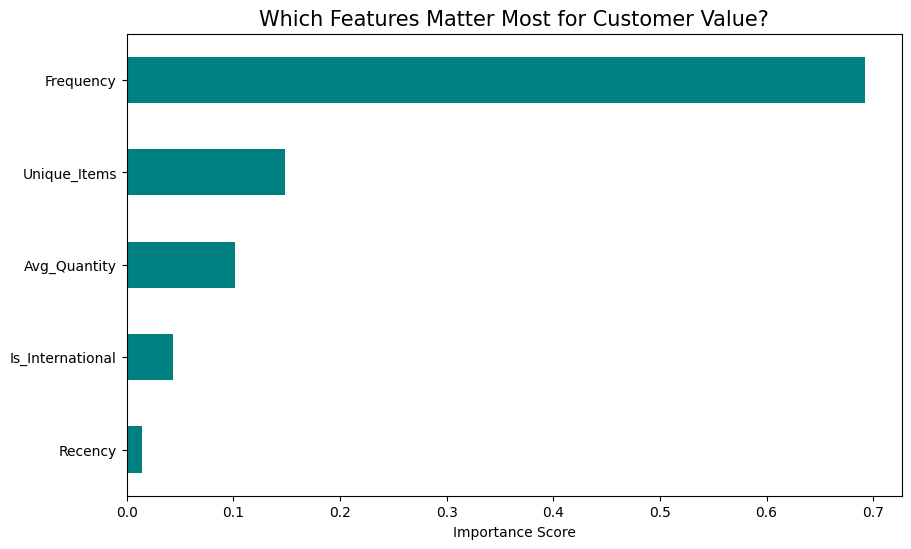

In [17]:
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Which Features Matter Most for Customer Value?', fontsize=15)
plt.xlabel('Importance Score')
plt.show()

In [18]:
scores = cross_val_score(best_xgb, X, y, cv=5)

print("Accuracy every time out of the five:", scores)
print("True Mean Accuracy:", scores.mean())

Accuracy every time out of the five: [0.80375812 0.8260526  0.80314596 0.78980121 0.78219309]
True Mean Accuracy: 0.8009901960998456


In [19]:
all_predictions = best_xgb.predict(X)
results = rfm_pro.copy()
results['Predicted_Monetary'] = all_predictions

top_10_customers = results.sort_values(by='Predicted_Monetary', ascending=False).head(10)

print("--- List of the Top 10 Prospective Clients for the Next Phase ---")
print(top_10_customers[['CustomerID', 'Monetary', 'Predicted_Monetary']])

--- List of the Top 10 Prospective Clients for the Next Phase ---
      CustomerID  Monetary  Predicted_Monetary
538      13198.0   3384.09         3260.278076
3405     17528.0   3540.10         3246.308105
582      13268.0   3167.64         3231.050781
2144     15622.0   3224.53         3217.653564
2799     16607.0   3038.67         3211.740723
3478     17644.0   2768.98         3167.386230
82       12473.0   2848.23         3153.586670
2382     15984.0   2816.97         3080.481934
855      13685.0   3119.44         3077.756348
3435     17576.0   3457.78         3074.813965
